# Linear-equivalent disc / annulus with cone linearization
**The experiment.** Every natural-image patch is shown three ways, interleaved:

| `stimulusTag` | what it is |
|---|---|
| `image` | the image patch itself |
| `intensity` | uniform disc at the linear-equivalent intensity (patch averaged over the RF) |
| `linConeIntensity` / `lin cone intensity` | uniform disc at the **cone-linearized** equivalent intensity — averaged after a Weber cone nonlinearity `I / (I + WeberConstant)` |

Comparing image against each disc asks how much of the cell's preference for the real image
survives when the averaging happens in cone-response space instead of intensity space. The
measure is the nonlinearity index per patch, exactly as `computeNLI` defines it:

$$\mathrm{NLI} = \frac{\mathrm{image} - \mathrm{disc}}{|\mathrm{image}| + |\mathrm{disc}|}$$

set to zero when neither response clears a recording-mode threshold

In [1]:
import contextlib
import io

import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

## 1. Find experiment dates and cells for one protocol

Set `PROC` to one of the three exact protocol names below. The fast compact table has one row
per experiment, cell, and short protocol. `date_index` numbers each experiment date so it can
be selected directly in Section 1a. Detailed block, amplifier, recording-mode, and FilterWheel
metadata are deferred until one date is selected, which keeps a kernel restart quick. For
`LinearEquivalentDisc`, blocks
without the `linearizeCones` option are the older unrelated experiment and are also excluded.

In [2]:
# Choose exactly one:
# 'LinearEquivalentAnnulus', 'LinearEquivalentDiscConeLin', or 'LinearEquivalentDisc'
PROC = 'LinearEquivalentAnnulus'

protocol_cells = led.find_protocol_cells(PROC, show=False)
protocol_cells.insert(
    0, 'date_index', pd.factorize(protocol_cells['exp_name'], sort=False)[0] + 1)
print(f'{PROC}: {len(protocol_cells)} cells across '  # compact restart path
      f'{protocol_cells.exp_name.nunique()} experiments')
sc.scroll_table(protocol_cells, height=420)

LinearEquivalentAnnulus: 84 cells across 37 experiments


date_index,exp_name,cell_label,protocol
1,2022-07-05_G,Cell2,LinearEquivalentAnnulus
1,2022-07-05_G,Cell4,LinearEquivalentAnnulus
1,2022-07-05_G,Cell5,LinearEquivalentAnnulus
1,2022-07-05_G,Cell6,LinearEquivalentAnnulus
1,2022-07-05_G,Cell7,LinearEquivalentAnnulus
1,2022-07-05_G,Cell8,LinearEquivalentAnnulus
1,2022-07-05_G,Cell9,LinearEquivalentAnnulus
2,2022-07-12_G,Cell1,LinearEquivalentAnnulus
2,2022-07-12_G,Cell2,LinearEquivalentAnnulus
2,2022-07-12_G,Cell3,LinearEquivalentAnnulus


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:420px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>protocol</th></tr></thead><tbody><tr><td>1</td><td>2022-07-05_G</td><td>Cell2</td><td>LinearEquivalentAnnulus</td></tr><tr><td>1</td><td>2022-07-05_G</td><td>Cell

### 1a. Choose a date and group its recordings

Choose one `date_index` from the Section 1 table. Only that date is grouped below, so the
overview is not repeated for every experiment. Each row is one cell × resolved recording
mode × disc site × light setting, with blocks from the same condition pooled. The tree table
keeps only: `exp_name`, `cell_label`, `cell_type_short`,
resolved `onlineAnalysis`, `site`, `light_settings`, `block_ids`, `image_names`, short
`protocols`, and protocol-setting `maxIntensity`. A blank `maxIntensity` means the older
protocol did not record that setting.

In [3]:
# Choose a date_index shown in Section 1.
DATE_INDEX = 36

date_rows = protocol_cells.loc[protocol_cells.date_index.eq(DATE_INDEX)]
if date_rows.empty:
    raise ValueError(f'date_index {DATE_INDEX} is not available for {PROC}')
EXP_NAME = date_rows.exp_name.iloc[0]

# Only now load detailed blocks and resolve recording mode from the amplifier.
df_blocks = led.find_blocks(
    exp_names=[EXP_NAME], protocols=[PROC], show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    df_blocks = led.check_series_resistance(
        df_blocks, show=False, sample_series_resistance=True)
selected_blocks = df_blocks.copy()
if selected_blocks.empty:
    raise ValueError(f'{EXP_NAME!r} is not available for {PROC}')
groups = led.group_blocks(selected_blocks)

28 recording groups (experiment x cell x mode x site x light level)


exp_name,cell_label,cell_type_short,onlineAnalysis,site,light_settings,block_ids,image_names,protocols,maxIntensity
2026-08-12_G,Cell1,ON-parasol,extracellular,surround,FW0/bg0.115072,37491,['02999'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.131325,37493,['03347'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.139055,37490,['02733'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.1473,37494,['03758'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.14899,37485,['01192'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.155824,37488,['01769'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.156863,37489,['01829'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.175873,37495,['03760'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.182263,37486,['01151'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.199407,37484,['00152'],LinearEquivalentAnnulus,77000.0


## 2. What the cell was shown

Continue from the date selected in Section 1a. The dropdown contains every recorded `imageName`
for that date; choosing one redraws an example patch and its two equivalent discs. The three
stimuli use a common grey scale: the natural-image patch as seen through
the aperture, the uniform disc at the linear-equivalent intensity, and the uniform disc at the
cone-linearized intensity. The image is loaded from the van Hateren resources in the turner
package the same way `NaturalImageFlashProtocol.m` does — big-endian `.iml`, rescaled so the
brightest pixel is 1, at 6.6 µm per image pixel.

A useful check that the geometry is right: the mean intensity inside the aperture should land on
the recorded `equivalentIntensity`, since that is what the equivalent disc is defined to be.

In [4]:
image_example = led.stimulus_example_widget(selected_blocks)
image_example

## 3. Analyze one cell condition

Enter the cell label, resolved `onlineAnalysis`, and numeric FilterWheel value. The first output
lists the matching block IDs and one row per `imageName`, including its epoch count and
`meanIntensity = maxIntensity × backgroundIntensity`.

Responses use the exact onset window from `preTime` through `preTime + stimTime`: spike count
for extracellular recordings and baseline-subtracted signed area (pA·s) for whole-cell
recordings. Each scatter point is one `(imageName, patchIndex)` pair; x and y error bars are
SEM across repeat epochs. The per-image and pooled figures show image vs standard disc in grey
and image vs cone-linearized disc in red, with a unity line. Patch indices that restart in a new
image remain separate. The final figure uses 50-bin NLI density lines and a second panel with
the mean ± SEM across every image-specific patch for this cell. After Section 3a has saved this
exact block set once, rerunning after a kernel restart reloads those patch results instead of
re-reading traces and detecting spikes. Pass `reuse_saved=False` to `analyze_condition` when a
deliberate raw-data recomputation is needed.

2026-08-12_G/Cell1 | extracellular | FilterWheel 0
block_ids: 37484, 37486, 37487, 37485, 37488, 37489, 37490, 37491, 37492, 37493, 37494, 37495
12 imageNames | 1440 epochs


imageName,block_ids,epochs,maxIntensity,backgroundIntensity,meanIntensity
00152,[37484],120,77000.0,0.19940717249552456,15354.35228215539
01151,[37486],120,77000.0,0.18226333396698993,14034.276715458225
01154,[37487],120,77000.0,0.2578482378959714,19854.314317989796
01192,[37485],120,77000.0,0.14898986739427206,11472.21978935895
01769,[37488],120,77000.0,0.1558242954745235,11998.47075153831
01829,[37489],120,77000.0,0.15686291769365707,12078.444662411594
02733,[37490],120,77000.0,0.13905522128372247,10707.252038846631
02999,[37491],120,77000.0,0.11507195997437214,8860.540918026654
03093,[37492],120,77000.0,0.201603688422656,15523.484008544512
03347,[37493],120,77000.0,0.13132452780078488,10111.988640660436


loaded 120 saved patch rows from /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/2026-08-12_G__Cell1__extracellular__surround__LinearEquivalentAnnulus__FW0.csv


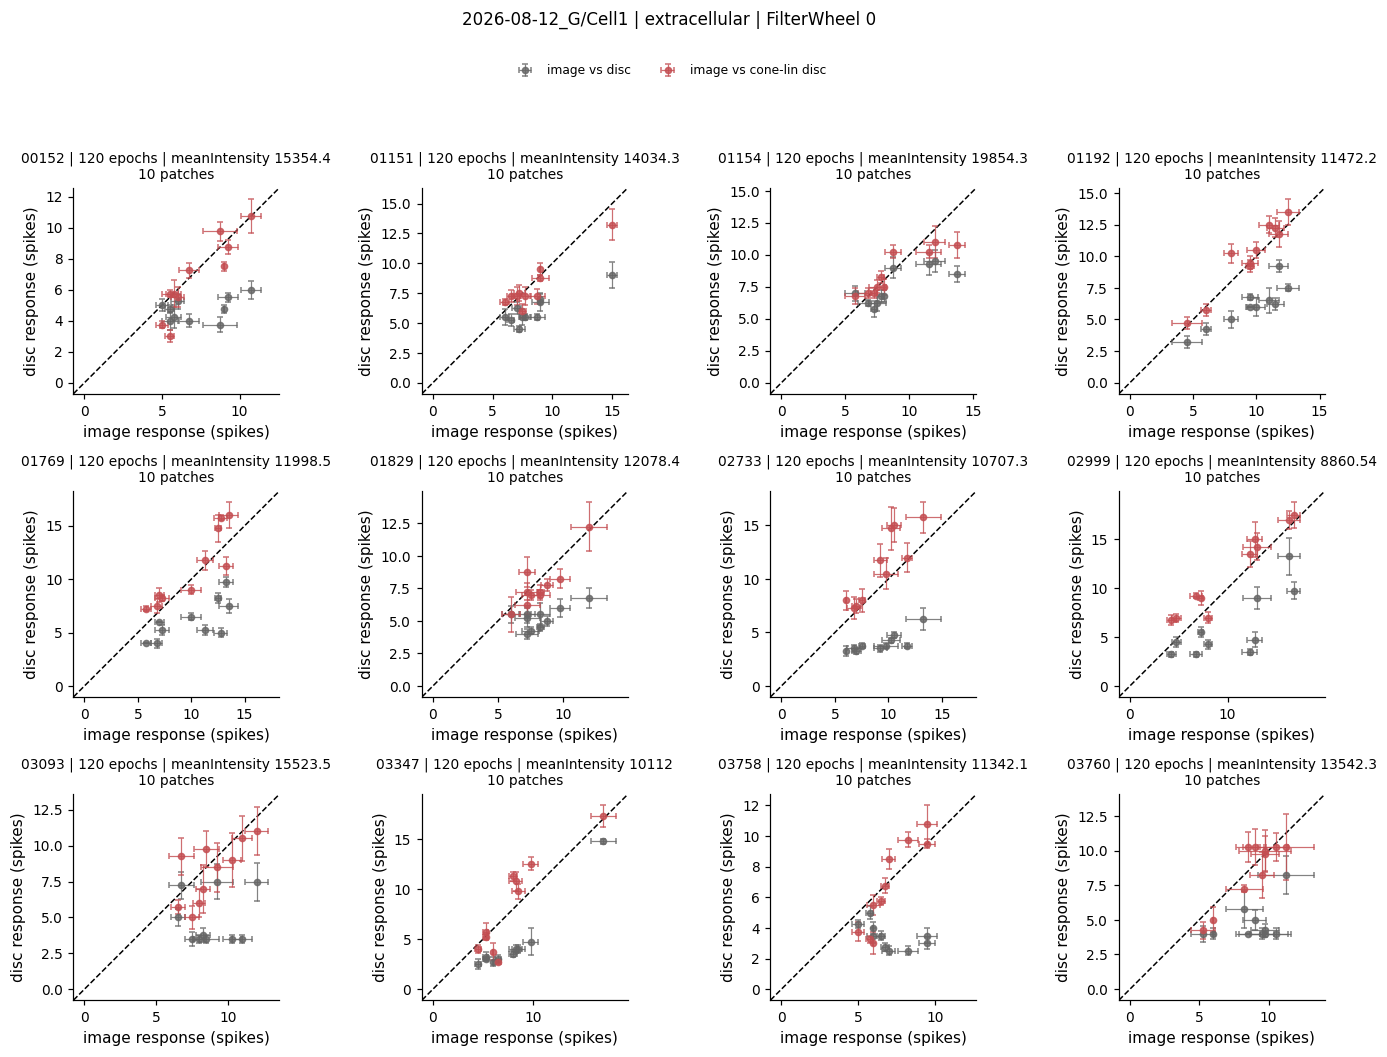

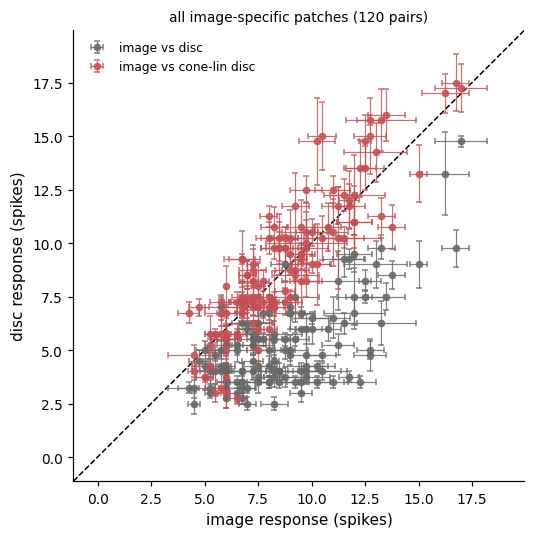

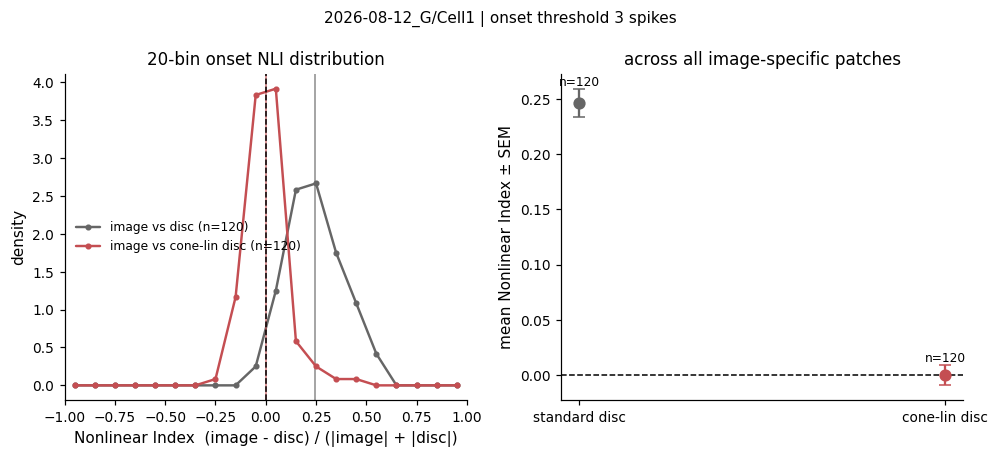

In [4]:
# Define one condition within the experiment selected in Section 1a.
CELL_LABEL = 'Cell1'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
FILTER_WHEEL_VALUE = 0.0           # authoritative numeric FilterWheel value

condition_blocks = led.select_condition_blocks(
    selected_blocks, CELL_LABEL, ONLINE_ANALYSIS, FILTER_WHEEL_VALUE)
condition = led.analyze_condition(condition_blocks)
image_fig, pooled_fig, nli_fig = led.plot_condition(condition)

### 3a. Save this cell for population analysis

Save one compressed HDF5 record for the selected cell condition, similar to a MATLAB struct
containing arrays. Cell metadata is stored once, and the image summary and patch responses are
kept as typed arrays instead of tens of thousands of CSV rows. `condition_population_table()`
still expands the selected condition for display when needed. Re-running this cell replaces the
same versioned condition file rather than duplicating it. It also becomes the fast
restart source for Section 3 when the selected block IDs match. Later,
`led.load_condition_outputs()` combines every saved cell into one population table.

In [5]:
condition_output_path = led.save_condition_output(condition)
population_ready = led.condition_population_table(condition)
sc.scroll_table(
    population_ready, height=360,
    num_cols=('filter_wheel_ndf', 'patchIndex', 'maxIntensity',
              'meanIntensity', 'image_response', 'disc_response',
              'cone_disc_response', 'nli_image_vs_disc',
              'nli_image_vs_cone_disc'));

saved 1 condition (120 patches as arrays) to /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/2026-08-12_G__Cell1__extracellular__surround__LinearEquivalentAnnulus__FW0.h5


date,cell_label,cell_type,onlineAnalysis,protocol,site,filter_wheel_ndf,imageName,patchIndex,patch_key,block_ids,image_epochs,maxIntensity,backgroundIntensity,meanIntensity,response_units,image_response,image_response_sem,image_trials,disc_response,disc_response_sem,disc_trials,cone_disc_response,cone_disc_response_sem,cone_disc_trials,nli_image_vs_disc,nli_image_vs_cone_disc,output_version
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,1.0,00152:1,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,5.75,0.478713553878169,4,4.25,0.75,4,5.75,0.8539125638299665,4,0.15,0.0,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,2.0,00152:2,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,6.0,0.408248290463863,4,5.25,0.478713553878169,4,5.5,0.6454972243679028,4,0.0666666666666666,0.0434782608695652,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,3.0,00152:3,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,9.0,0.0,4,4.75,0.25,4,7.5,0.2886751345948128,4,0.3090909090909091,0.0909090909090909,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,4.0,00152:4,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,8.75,1.1086778913041726,4,3.75,0.478713553878169,4,9.75,0.6291528696058958,4,0.4,-0.054054054054054,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,5.0,00152:5,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,5.5,0.5,4,4.0,0.5773502691896257,4,5.75,0.25,4,0.1578947368421052,-0.0222222222222222,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,6.0,00152:6,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,6.75,0.6291528696058958,4,4.0,0.408248290463863,4,7.25,0.478713553878169,4,0.2558139534883721,-0.0357142857142857,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,7.0,00152:7,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,10.75,0.6291528696058958,4,6.0,0.5773502691896257,4,10.75,1.1086778913041726,4,0.2835820895522388,0.0,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,8.0,00152:8,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,5.0,0.408248290463863,4,5.0,0.408248290463863,4,3.75,0.25,4,0.0,0.1428571428571428,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,9.0,00152:9,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,5.5,0.2886751345948128,4,4.75,0.25,4,3.0,0.408248290463863,4,0.073170731707317,0.2941176470588235,1
2026-08-12_G,Cell1,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,10.0,00152:10,37484,120,77000.0,0.1994071724955245,15354.35228215539,spikes,9.25,0.6291528696058958,4,5.5,0.2886751345948128,4,8.75,0.478713553878169,4,0.2542372881355932,0.0277777777777777,1


## 4. Batch analyze and save

Records go to `<OUTPUT_DIR>/linear_equivalent_disc/records.h5` with a `summary.csv` index,
upserted per (experiment, cell, mode, site, filter wheel, background) — same layout as the other
protocols, in its own directory. `skip_existing` makes re-running the notebook cheap.

In [ ]:
records = led.analyze_all(groups, save=True, plot=False, skip_existing=True)

## 5. Population: does cone linearization remove the nonlinearity?

Section 1 of `populationLinConeDisc.m`: one line per recording joining its mean standard-disc
NLI to its mean cone-linearized NLI, per recording mode, with a paired Wilcoxon signed-rank
test. If cone linearization captures what the cell is doing, the cone-linearized NLI should sit
closer to zero.

In [ ]:
summary = led.load_summary()
print(f'{len(summary)} stored recordings')
led.plot_population_nli(summary, window='onset');

In [ ]:
led.plot_population_nli(summary, window='offset');

### Pooled per-patch distributions

Section 2 of the population script — every patch from every recording, no per-cell averaging,
with a two-sample KS test.

In [ ]:
led.plot_nli_distributions(window='onset');

### Split by disc site

The annulus protocol puts the disc over the surround; the other two put it over the centre.
Those are different experiments and are worth looking at separately.

In [ ]:
for site in sorted(summary['site'].unique()):
    sub = summary[summary['site'].eq(site)]
    print(f'--- disc over {site}: {len(sub)} recordings ---')
    display(sub.groupby('online_analysis')[['nli_disc_onset', 'nli_cone_onset',
                                            'nli_disc_offset', 'nli_cone_offset']]
               .agg(['count', 'mean']).round(3))

## 6. Come back later

`load_summary()` reads the scalar index with no DataJoint or SSD access; `load_records()` pulls
the per-patch arrays.

In [ ]:
cols = ['exp_name', 'cell_label', 'cell_type', 'online_analysis', 'online_analysis_recorded',
        'site', 'light_setting', 'max_intensity', 'series_resistance', 'n_patches',
        'nli_disc_onset', 'nli_cone_onset']
sc.scroll_table(summary[[c for c in cols if c in summary.columns]], height=320)

## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-04-03_E/Cell4'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [ ]:
led.list_cells(groups)

In [ ]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-04-03_E/Cell4'

cell_records = led.inspect_cell(CELL, groups)